# LING 498 Hackathon — Prompt 6

## POS tags as Zipf objects

**Category:** Syntax (tagging)

**Question:** Does the distribution of POS tags look Zipf-like, and how does it compare to words?

- **Data:** Brown (or your own text). Use a filtered token list.
- **Items to Count:** POS tags from `nltk.pos_tag(tokens)` (count tags only).

**Steps**
- Tokenize + filter punctuation.
- POS-tag tokens.
- Count tags; run Zipf report/plot.
- Interpret: why POS may be “flatter” (smaller inventory; abstraction level).

**Deliverable:** Top-15 tags + 3-sentence comparison to word Zipf (Prompt 1).

In [12]:
import re
import nltk
from nltk.corpus import brown
from nltk import FreqDist

# download the following if needed for POS tagging
# nltk.download("averaged_perceptron_tagger_eng") 

tokens = brown.words()

In [ ]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Tag Types: {len(ranked)} | Tags: {sum(c for _,c in ranked)}")
    print("Top tags:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [14]:
# Filter tokens that are only punctuation
words = [
    token
    for token in tokens
    if not re.fullmatch(r"\W+", token) 
]

In [15]:
# POS-tag with tokens
tagged = nltk.pos_tag(words)

In [16]:
# Extract only the POS tags
tags = []

for word, tag in tagged:
    tags.append(tag)
print(tags[:10])

['DT', 'NNP', 'NNP', 'NNP', 'NNP', 'VBD', 'NNP', 'DT', 'NN', 'IN']


In [17]:
print(f"{len(tokens)} tokens from Brown corpus")
print(f"{len(tagged)} tagged tokens")

1161192 tokens from Brown corpus
1013319 tagged tokens



=== Brown Corpus POS Tags ===
Tag Types: 36 | Tags: 1013319
Top tags:
 1. NN                                       156814
 2. IN                                       136431
 3. DT                                       114727
 4. JJ                                       80742
 5. NNP                                      76573
 6. NNS                                      54353
 7. VBD                                      47309
 8. RB                                       45123
 9. PRP                                      44085
10. CC                                       37961
11. VB                                       34448
12. VBN                                      27108
13. TO                                       26158
14. VBZ                                      21585
15. VBG                                      17965

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.575
 f1/(3*f3) = 0.456
 f1/(4*f4) = 0.486
 f1/(5*f5) = 0.41


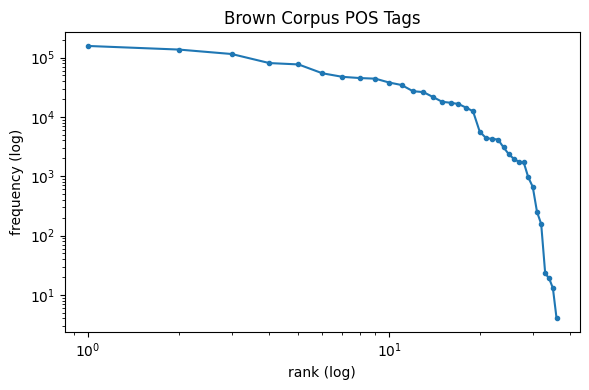

In [18]:
ranked = zipf_quick_report(tags, title="Brown Corpus POS Tags")
zipf_plot(ranked, title="Brown Corpus POS Tags")

### Interpretation

The POS tag distribution follows a Zipf-like pattern, with a small number of tags such as `NN`, `IN`, and `DT` occurring much more frequently than the rest. These tags appear often because nouns, prepositions, and determiners are needed in many English sentences. Compared with the word Zipf distribution from Prompt 1, the POS tag distribution is flatter because there are far fewer POS tags than there are unique words. While words have a very large vocabulary with many rare word types, the set of POS tags is small, so the same tags are reused throughout the corpus. This shows that changing the unit of analysis—from words to grammatical categories—changes the shape of the Zipf distribution.